In [1]:
import io
import sys
from contextlib import redirect_stdout
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import pingouin as pg
import requests
from shapely.geometry import Polygon
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import contextily as cx
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

# Clusters

Se corre algoritmo K-means para encontrar las regiones del país y poder hacer las respectivas divisiones para estudio

In [2]:
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn import linear_model
from sklearn import model_selection as ms
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [3]:
# Reading all sat condulted data

r = pd.read_csv(r'colombia_prom_filtered.csv', usecols=(2,3,5),delimiter=',') # se carga el archivo .csv
r = r[r['longitude'] >= -80] # se elimina gorgona
r

,latitude,longitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-4.165,-69.995,1940.140508
1,-4.155,-70.005,1940.140503
2,-4.135,-69.965,1879.711405
3,-4.135,-69.955,1879.711295
4,-4.135,-69.945,1879.711346
...,...,...,...
494249,12.415,-71.585,1941.189894
494250,12.415,-71.575,1940.603705
494251,12.425,-71.605,1944.441511
494252,12.425,-71.595,1944.023515


In [4]:
# En caso de que no sean los datos corregidos:

#r['date']=pd.to_datetime(r['date'])
#r = r.groupby(['longitude','latitude']).mean(['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']).reset_index()


In [5]:
X = r[['longitude', 'latitude', 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected']].to_numpy()

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### El siguiente script se ejecuta al final para obtener el k optimo

# --------------------------------------------------------------------------

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from kneed import KneeLocator
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Store evaluation metrics
inertias = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []
K = range(2, 10)

# Calculate metrics for each k
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    
    # Store metrics
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))


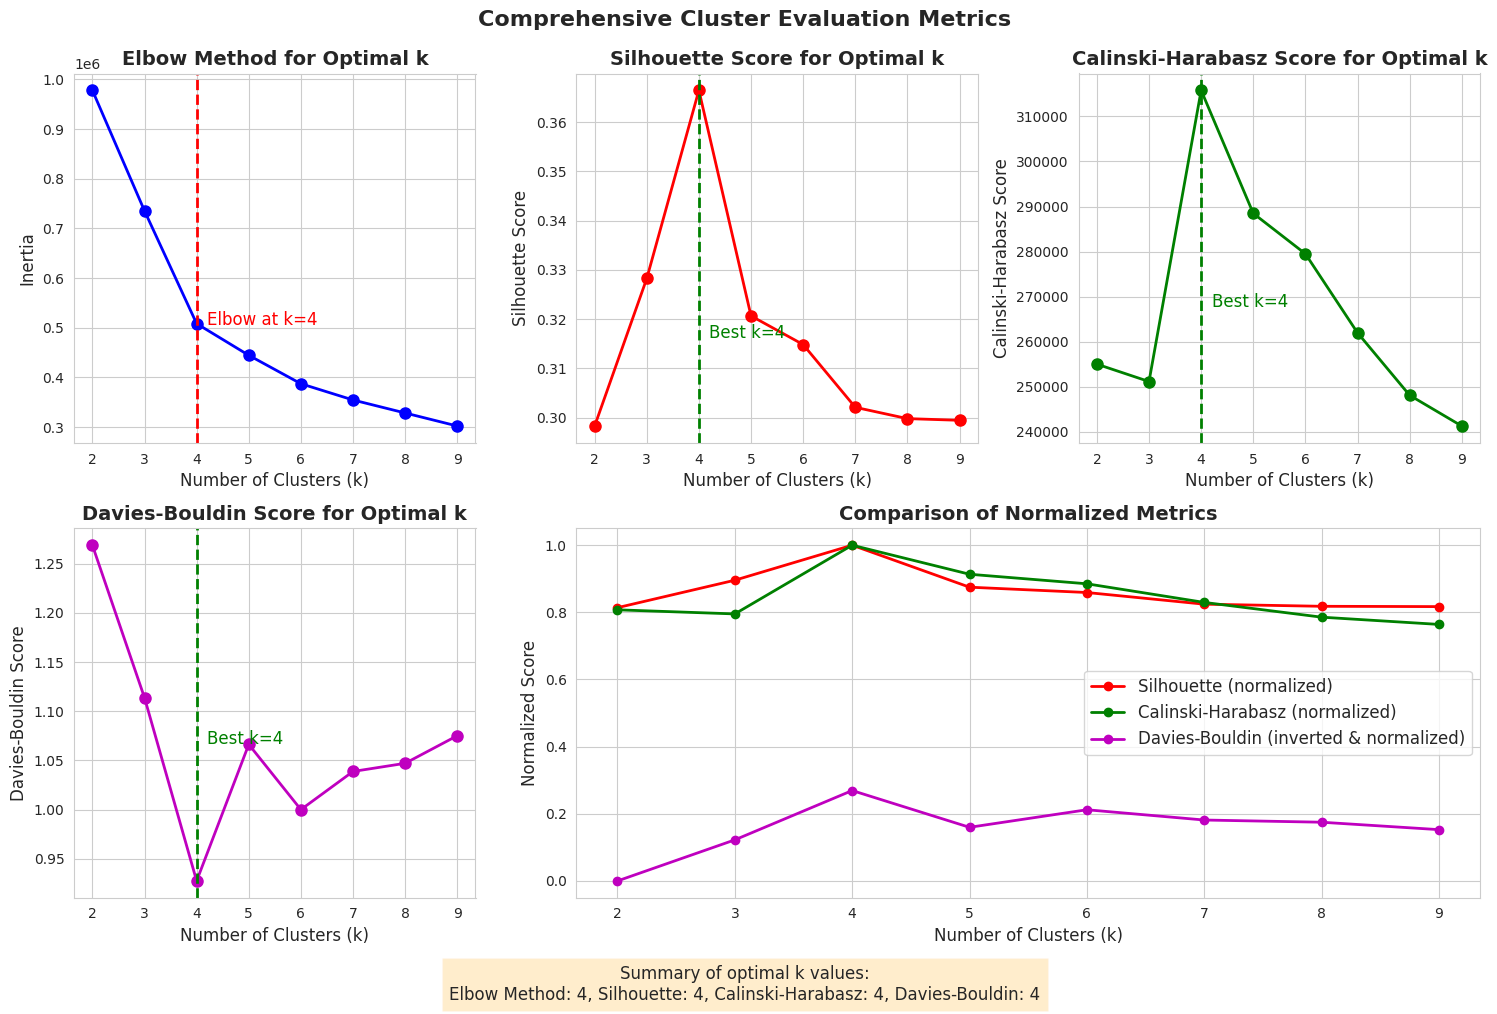

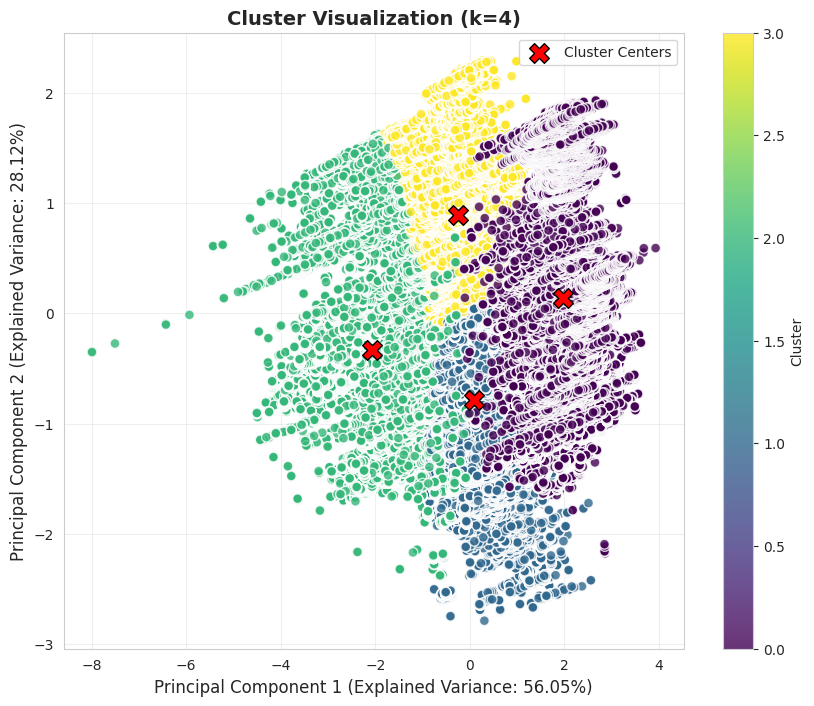

In [12]:
# Set up the figure with GridSpec for better control
plt.figure(figsize=(15, 10))
gs = GridSpec(2, 3, figure=plt.gcf())

# Set style
sns.set_style("whitegrid")
#plt.rcParams['font.family'] = 'sans-serif'
#plt.rcParams['font.sans-serif'] = ['Arial']

# Plot 1: Elbow Method with detected knee point
ax1 = plt.subplot(gs[0, 0])
ax1.plot(K, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')

# Automatic knee/elbow detection
kneedle = KneeLocator(K, inertias, curve='convex', direction='decreasing')
if kneedle.knee:
    ax1.axvline(x=kneedle.knee, color='r', linestyle='--', linewidth=2)
    ax1.text(kneedle.knee+0.2, np.mean(inertias), f'Elbow at k={kneedle.knee}', 
             fontsize=12, color='r')

# Plot 2: Silhouette Score
ax2 = plt.subplot(gs[0, 1])
ax2.plot(K, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score for Optimal k', fontsize=14, fontweight='bold')
best_k_sil = K[np.argmax(silhouette_scores)]
ax2.axvline(x=best_k_sil, color='g', linestyle='--', linewidth=2)
ax2.text(best_k_sil+0.2, np.mean(silhouette_scores), f'Best k={best_k_sil}', 
         fontsize=12, color='g')

# Plot 3: Calinski-Harabasz Score
ax3 = plt.subplot(gs[0, 2])
ax3.plot(K, calinski_scores, 'go-', linewidth=2, markersize=8)
ax3.set_xlabel('Number of Clusters (k)', fontsize=12)
ax3.set_ylabel('Calinski-Harabasz Score', fontsize=12)
ax3.set_title('Calinski-Harabasz Score for Optimal k', fontsize=14, fontweight='bold')
best_k_ch = K[np.argmax(calinski_scores)]
ax3.axvline(x=best_k_ch, color='g', linestyle='--', linewidth=2)
ax3.text(best_k_ch+0.2, np.mean(calinski_scores), f'Best k={best_k_ch}', 
         fontsize=12, color='g')

# Plot 4: Davies-Bouldin Score (lower is better)
ax4 = plt.subplot(gs[1, 0])
ax4.plot(K, davies_bouldin_scores, 'mo-', linewidth=2, markersize=8)
ax4.set_xlabel('Number of Clusters (k)', fontsize=12)
ax4.set_ylabel('Davies-Bouldin Score', fontsize=12)
ax4.set_title('Davies-Bouldin Score for Optimal k', fontsize=14, fontweight='bold')
best_k_db = K[np.argmin(davies_bouldin_scores)]
ax4.axvline(x=best_k_db, color='g', linestyle='--', linewidth=2)
ax4.text(best_k_db+0.2, np.mean(davies_bouldin_scores), f'Best k={best_k_db}', 
         fontsize=12, color='g')

# Plot 5: Combined view with normalized scores
ax5 = plt.subplot(gs[1, 1:])
# Normalize metrics for comparison
norm_silhouette = np.array(silhouette_scores) / max(silhouette_scores)
norm_calinski = np.array(calinski_scores) / max(calinski_scores)
norm_davies = 1 - (np.array(davies_bouldin_scores) / max(davies_bouldin_scores))  # Invert as lower is better

ax5.plot(K, norm_silhouette, 'ro-', linewidth=2, label='Silhouette (normalized)')
ax5.plot(K, norm_calinski, 'go-', linewidth=2, label='Calinski-Harabasz (normalized)')
ax5.plot(K, norm_davies, 'mo-', linewidth=2, label='Davies-Bouldin (inverted & normalized)')
ax5.set_xlabel('Number of Clusters (k)', fontsize=12)
ax5.set_ylabel('Normalized Score', fontsize=12)
ax5.set_title('Comparison of Normalized Metrics', fontsize=14, fontweight='bold')
ax5.legend(fontsize=12)
ax5.grid(True)

# Add a summary for best k values from each method
plt.figtext(0.5, -0.01, f"Summary of optimal k values:\nElbow Method: {kneedle.knee if kneedle.knee else 'Not clearly detected'}, "
                      f"Silhouette: {best_k_sil}, Calinski-Harabasz: {best_k_ch}, Davies-Bouldin: {best_k_db}", 
            ha="center", fontsize=12, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.suptitle('Comprehensive Cluster Evaluation Metrics', fontsize=16, fontweight='bold', y=0.98)
plt.savefig('comprehensive_clusters_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional: Add cluster visualization for the optimal k
optimal_k = best_k_sil  # Choose the method you trust most or take consensus
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_optimal = kmeans_optimal.fit_predict(X_scaled)

# If your data is high-dimensional, use PCA or t-SNE for visualization
from sklearn.decomposition import PCA

# For 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_optimal, cmap='viridis', 
                     s=50, alpha=0.8, edgecolors='w')
plt.colorbar(scatter, label='Cluster')

# Plot cluster centers (transformed to PCA space)
centers_pca = pca.transform(kmeans_optimal.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], s=200, marker='X', c='red', 
           edgecolors='black', label='Cluster Centers')

plt.title(f'Cluster Visualization (k={optimal_k})', fontsize=14, fontweight='bold')
plt.xlabel(f'Principal Component 1 (Explained Variance: {pca.explained_variance_ratio_[0]:.2%})', fontsize=12)
plt.ylabel(f'Principal Component 2 (Explained Variance: {pca.explained_variance_ratio_[1]:.2%})', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('cluster_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

### A partir de aqui se ejecuta asumiendo que el k optimo es tres, buscando analizar el comportamiento de tres regiones principales.

In [6]:
# Fit final model with optimal k (let's say k=3 after analysis)
optimal_k = 3  # Change this based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=50, n_init=100)
kmeans.fit(X_scaled)

# Add labels to original dataframe
r['cluster'] = kmeans.labels_
labe = kmeans.labels_



In [7]:
# Get the path to the file one directory up
# Get current working directory and go up one level
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
file_path = os.path.join(parent_dir, 'common/Departamentos_Junio_2024_shp/Departamento.shp')


# Load the file into a GeoDataFrame
gdf = gpd.read_file(file_path)

GeoDataFrame already has CRS: PROJCS["MAGNA-SIRGAS_2018_Origen-Nacional",GEOGCS["MAGNA-SIRGAS_2018",DATUM["Marco_Geocentrico_Nacional_de_Referencia_2018",SPHEROID["GRS_1980",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4],PARAMETER["central_meridian",-73],PARAMETER["scale_factor",0.9992],PARAMETER["false_easting",5000000],PARAMETER["false_northing",2000000],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


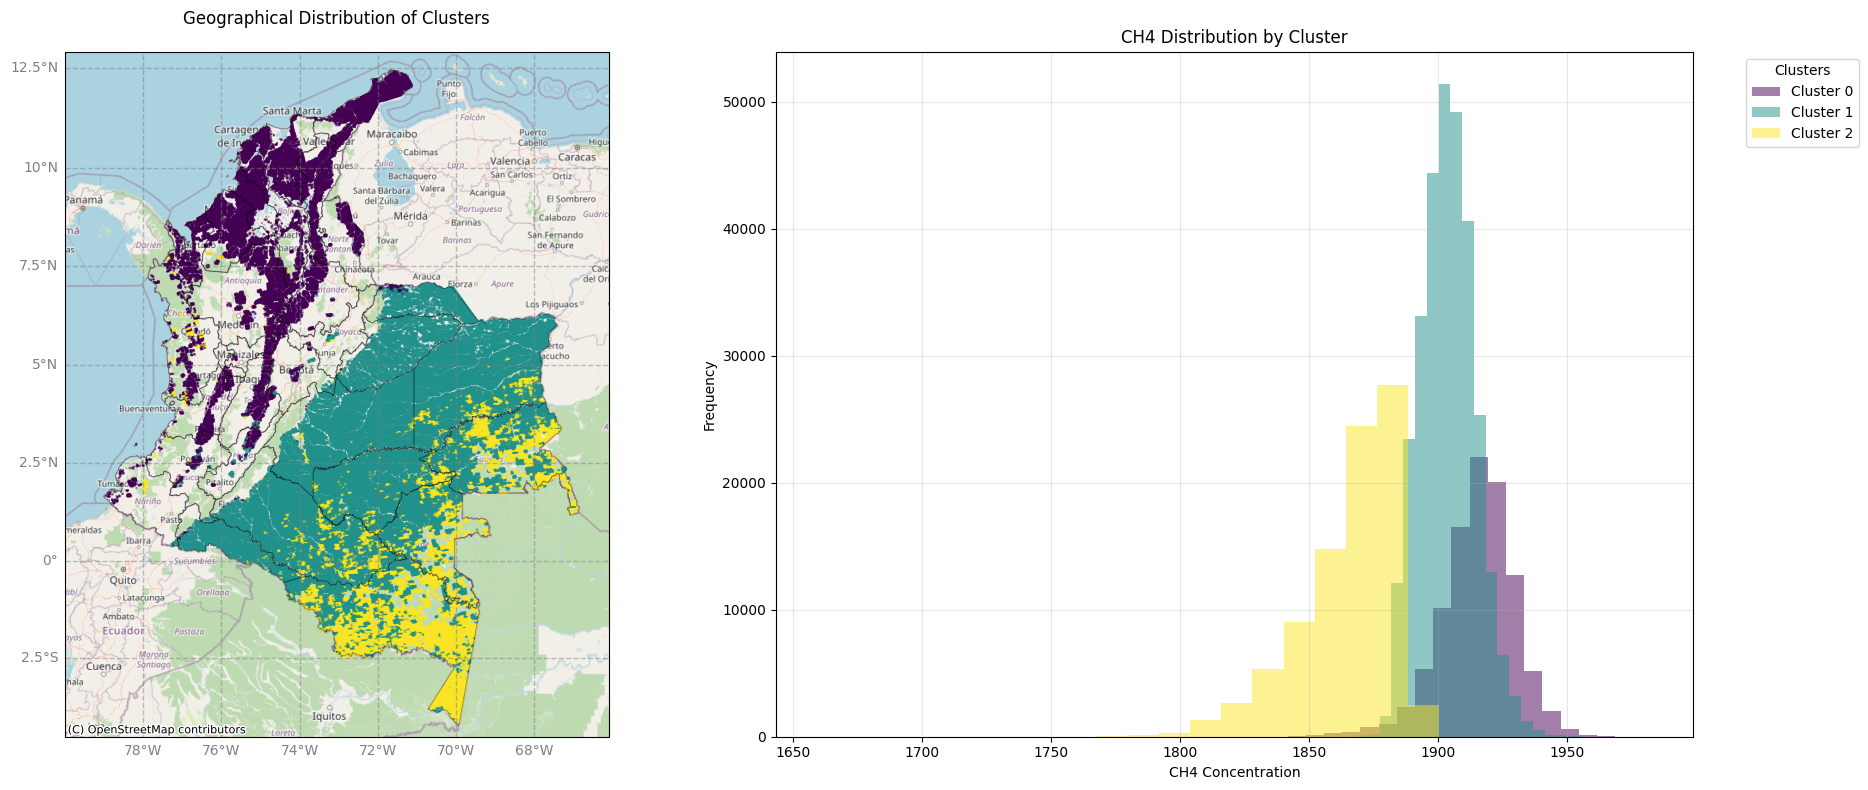


Cluster Statistics:
        CH4_column_volume_mixing_ratio_dry_air_bias_corrected                 \
                                                         mean    std   count   
cluster                                                                        
0                                                  1915.46     14.32   99682   
1                                                  1903.82     10.57  306169   
2                                                  1865.08     18.75   88395   

        longitude latitude  
             mean     mean  
cluster                     
0          -74.66     8.18  
1          -71.79     2.66  
2          -70.88     0.07  


In [8]:
# Create figure and axes
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, figure=fig)

# First subplot - Map with clusters
ax1 = fig.add_subplot(gs[0], projection=ccrs.epsg(3857))

# Set map extent
extent = [-80, -66.1, -4.5, 12.9]
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Create GeoDataFrame from your clusters data
gdf_points = gpd.GeoDataFrame(
    r,
    geometry=gpd.points_from_xy(r.longitude, r.latitude),
    crs="EPSG:4326"
)

# Convert to web mercator for contextily basemap
gdf_points_mercator = gdf_points.to_crs(epsg=3857)

# Define cluster colors
clusters = gdf_points['cluster'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))

# Plot clusters on map
# for cluster, color in zip(clusters, colors):
#     cluster_data = gdf_points[gdf_points['cluster'] == cluster]
#     ax1.scatter(
#         cluster_data.longitude,
#         cluster_data.latitude,
#         color=color,
#         label=f'Cluster {cluster}',  # Add cluster number as label
#         transform=ccrs.PlateCarree(),
#         s=5,  # Marker size
#         alpha=0.6
#     )
    
# Plot clusters on map
scatter = ax1.scatter(
                        gdf_points.longitude,
                        gdf_points.latitude,
                        c=gdf_points.cluster,
                        cmap='viridis',
                        alpha=0.6,
                        transform=ccrs.PlateCarree(),
                        s=0.05  # Marker size, smaller values mean smaller circles
                    )

# Add basemap 
cx.add_basemap(ax1, 
               source=cx.providers.OpenStreetMap.Mapnik)

# Add gridlines
gl = ax1.gridlines(crs=ccrs.PlateCarree(), 
                   draw_labels=True,
                   linewidth=1, 
                   color='gray', 
                   alpha=0.5, 
                   linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Add colorbar to map
# cbar = plt.colorbar(scatter, ax=ax1)
# cbar.set_label('Cluster', fontsize=10)

# Add legend to map
# legend = ax1.legend(title='Clusters', loc='upper right', bbox_to_anchor=(1.15, 1))
# plt.setp(legend.get_title(), fontsize=10)  # Adjust legend title font size

if gdf.crs is None:
    # Only set CRS if it doesn't have one
    gdf.set_crs(epsg=4326, inplace=True)
else:
    print("GeoDataFrame already has CRS:", gdf.crs)
gdf = gdf.to_crs(epsg=3857)
              
gdf.plot(ax=ax1, edgecolor='black', facecolor='none', linewidth=0.5, alpha=0.4)


# Add title to map
ax1.set_title('Geographical Distribution of Clusters', pad=20)





# Second subplot - Methane distribution
ax2 = fig.add_subplot(gs[1])
colors = plt.cm.viridis(np.linspace(0, 1, optimal_k))  # Use same colormap as map

ax2.set_xlabel('CH4 Concentration')
ax2.set_ylabel('Frequency')
ax2.set_title('CH4 Distribution by Cluster')


for i in range(optimal_k):
    cluster_data = r[r['cluster'] == i]
    ax2.hist(cluster_data['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'], 
             alpha=0.5, 
             label=f'Cluster {i}',
             color=colors[i],  # Match colors with map
             bins=20)  # Adjust number of bins

# Add grid to histogram
ax2.grid(True, alpha=0.3)

# Customize histogram legend
ax2.legend(title='Clusters', 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left')

# Adjust layout and save
plt.tight_layout()
plt.savefig('clusters_definitiva_3.png', dpi=300, bbox_inches='tight')
plt.show()

# Print cluster statistics
print("\nCluster Statistics:")
print(r.groupby('cluster').agg({
    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected': ['mean', 'std', 'count'],
    'longitude': 'mean',
    'latitude': 'mean'
}).round(2))

# Clasificación

Debido a que anteriormente, ningún clasificador hizo un buen trabajo, y simplemente tomaba toda la región del país como perteneciente a una misma intancia, se busca crear una red neuronal que haga la tarea de clasificación.

In [9]:
import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import itertools

In [10]:
#X = r[['longitude', 'latitude', 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected']].to_numpy()
y= r['cluster'].to_numpy()
X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)

In [11]:
X_train.shape

(331144, 2)

In [12]:
class Data(Dataset):
  def __init__(self, X_train, y_train):
    # need to convert float64 to float32 else
    # will get the following error
    # RuntimeError: expected scalar type Double but found Float
    self.X = torch.from_numpy(X_train.astype(np.float32))
    # need to convert float64 to Long else
    # will get the following error
    # RuntimeError: expected scalar type Long but found Float
    self.y = torch.from_numpy(y_train).type(torch.LongTensor)
    self.len = self.X.shape[0]

  def __getitem__(self, index):
    return self.X[index], self.y[index]
  def __len__(self):
    return self.len

In [13]:
traindata = Data(X_train, Y_train)
print(traindata[25])

(tensor([-74.5450,   6.5350]), tensor(0))


In [14]:

# number of features (len of X cols)
input_dim = 2

# number of classes (unique of y)
output_dim = len(np.unique(Y_train))

class Network(nn.Module):
    def __init__(self, hidden_layers, dropout_rate=0.2):
        super(Network, self).__init__()
        
        # First hidden layer
        self.linear1 = nn.Linear(input_dim, hidden_layers[0])
        self.bn1 = nn.BatchNorm1d(hidden_layers[0])
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # Second hidden layer
        self.linear2 = nn.Linear(hidden_layers[0], hidden_layers[1])
        self.bn2 = nn.BatchNorm1d(hidden_layers[1])
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # Output layer
        self.linear3 = nn.Linear(hidden_layers[1], output_dim)
        
    def forward(self, x):
        # First layer
        x = self.linear1(x)
        x = self.bn1(x)
        x = F.leaky_relu(x)
        x = self.dropout1(x)
        
        # Second layer
        x = self.linear2(x)
        x = self.bn2(x)
        x = F.leaky_relu(x)
        x = self.dropout2(x)
        
        # Output layer
        x = self.linear3(x)
        
        return x


In [39]:
def run_training(epochs, learning_rate, clf, trainloader, val_loader=None, patience=5):
    """
    Train a neural network classifier over multiple epochs
    
    Parameters:
    - epochs: Total number of training epochs
    - learning_rate: Learning rate for the optimizer
    - clf: The neural network classifier model
    - trainloader: DataLoader containing the training data
    """
    criterion = nn.CrossEntropyLoss()  # Changed from MultiMarginLoss
    optimizer = torch.optim.Adam(clf.parameters(), lr=learning_rate)
    # Add learning rate scheduler - ReduceLROnPlateau
    # This reduces learning rate when validation loss stops improving
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',           # Minimize validation loss
        factor=0.5,           # Multiply learning rate by this factor when reducing
        patience=3,           # Number of epochs with no improvement after which LR will be reduced
        verbose=True,         # Print message when LR is reduced
        min_lr=1e-6           # Don't reduce LR below this value
    )

    # Early stopping variables
    best_val_loss = float('inf')
    early_stop_counter = 0
    best_model_state = None
    epochs_used = epochs  # Default to max epochs
    
    for epoch in range(epochs):

        # Set model to training mode
        clf.train()
        
        running_loss = 0.0
        batch_count = 0
        
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            
            # set optimizer to zero grad to remove previous epoch gradients
            optimizer.zero_grad()
            
            # forward propagation
            outputs = clf(inputs)
            loss = criterion(outputs, labels)
            
            # backward propagation
            loss.backward()
            
            # optimize
            optimizer.step()
            
            running_loss += loss.item()
            batch_count += 1
            
        # display statistics after each epoch
        avg_train_loss = running_loss / batch_count
        print(f'Epoch [{epoch + 1}/{epochs}] training loss: {avg_train_loss:.5f}')
        
        # Validation phase - if validation loader is provided
        if val_loader is not None:
            val_loss = validate(clf, val_loader, criterion)
            print(f'Epoch [{epoch + 1}/{epochs}] validation loss: {val_loss:.5f}')
            
            # Update learning rate based on validation loss
            scheduler.step(val_loss)

            # Early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                early_stop_counter = 0
                # Save the best model
                best_model_state = clf.state_dict().copy()
                print(f'New best model saved with validation loss: {val_loss:.5f}')
            else:
                early_stop_counter += 1
                print(f'Early stopping counter: {early_stop_counter}/{patience}')
                
            if early_stop_counter >= patience:
                print(f'Early stopping triggered after {epoch + 1} epochs')
                epochs_used = epoch + 1  # Record how many epochs were actually used
                # Load the best model before returning
                clf.load_state_dict(best_model_state)
                break
                
            # Print current learning rate
            current_lr = optimizer.param_groups[0]['lr']
            print(f'Current learning rate: {current_lr:.6f}')
        else:
            # If no validation set, use training loss for scheduler
            scheduler.step(avg_train_loss)
        # If we completed all epochs without early stopping, load the best model
        
    if early_stop_counter < patience and best_model_state is not None:
        clf.load_state_dict(best_model_state)
        print("Training completed. Loading best model.")
    else:
        print(f'Training completed after {epoch + 1} epochs')
    
    return best_val_loss, epochs_used
    

In [26]:
# Add validation function
def validate(model, val_loader, criterion):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    batch_count = 0
    
    with torch.no_grad():  # Disable gradient calculation
        for data in val_loader:
            inputs, labels = data
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            batch_count += 1
    
    return running_loss / batch_count

In [33]:
def test_val(clf, testloader):
    correct, total = 0, 0
    # no need to calculate gradients during inference
    with torch.no_grad():
      for data in testloader:
        inputs, labels = data
        # calculate output by running through the network
        outputs = clf(inputs)
        # get the predictions
        __, predicted = torch.max(outputs.data, 1)
        # update results
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # Use the testloader's dataset size instead of testdata
    print(f'Accuracy of the network on the {len(testloader.dataset)} test data: {100 * correct // total} %')
    return correct/total
    

In [48]:
def parameters_train(epochs, ta, hl_sizes, dropout_rate, trainloader, val_loader, testloader, patience=5):
    clf = Network(hl_sizes, dropout_rate)
    lr = ta
    best_val_loss, epochs_used = run_training(epochs, lr, clf, trainloader, val_loader, patience)
    score = test_val(clf, testloader)
    return score, best_val_loss, epochs_used

### --------------------------------

In [35]:
def optimize_layer_architecture(
    X, y, 
    layer1_sizes=range(16, 129, 16),  # First layer sizes to try
    layer2_sizes=range(8, 65, 8),     # Second layer sizes to try
    epochs=40,
    lr=0.005,
    dropout_rate=0.2,
    batch_size=20000,
    cv=5,                             # Cross validation folds
    patience=5                        # Early stopping patience
):
    """
    Find optimal number of neurons for each layer in a two-layer neural network.
    
    Args:
        X: Input features
        y: Target labels
        layer1_sizes: Range of neuron counts to try for first hidden layer
        layer2_sizes: Range of neuron counts to try for second hidden layer
        epochs: Maximum number of epochs for training
        lr: Learning rate
        dropout_rate: Dropout probability
        batch_size: Batch size for training
        cv: Number of cross-validation folds
        patience: Early stopping patience
        
    Returns:
        best_architecture: Dictionary containing optimal layer sizes and performance
        results: Full results for all architectures tested
    """
    # Store all results
    results = []
    
    # Try all combinations of layer sizes
    for layer1_size, layer2_size in itertools.product(layer1_sizes, layer2_sizes):
        print(f"\nTesting architecture: [{layer1_size}, {layer2_size}]")
        
        # Cross validation scores
        cv_scores = []
        cv_val_losses = []
        
        # Run cross-validation
        for j in range(cv):
            print(f"  CV fold {j+1}/{cv}")
            
            # Split data into train, validation, and test sets
            X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
            X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2)
            
            # Create data loaders
            traindata = Data(X_train, Y_train)
            valdata = Data(X_val, Y_val)
            testdata = Data(X_test, Y_test)
            
            trainloader = DataLoader(traindata, batch_size=batch_size, shuffle=True, num_workers=10)
            val_loader = DataLoader(valdata, batch_size=batch_size, shuffle=False, num_workers=10)
            testloader = DataLoader(testdata, batch_size=batch_size, shuffle=False, num_workers=10)
            
            # Train the model with this architecture
            score, val_loss, epochs_used = parameters_train(
                epochs=epochs,
                ta=lr,
                hl_sizes=[layer1_size, layer2_size],
                dropout_rate=dropout_rate,
                trainloader=trainloader,
                val_loader=val_loader,
                testloader=testloader,
                patience=patience
            )
            
            cv_scores.append(score)
            cv_val_losses.append(val_loss)
        
        # Calculate average performance across CV folds
        mean_score = np.mean(cv_scores)
        std_score = np.std(cv_scores)
        mean_val_loss = np.mean(cv_val_losses)
        
        print(f"Architecture [{layer1_size}, {layer2_size}] - "
              f"Avg Accuracy: {mean_score:.4f} ± {std_score:.4f}, "
              f"Avg Val Loss: {mean_val_loss:.4f}")
        
        # Store results
        results.append({
            'layer1_size': layer1_size,
            'layer2_size': layer2_size,
            'mean_accuracy': mean_score,
            'std_accuracy': std_score,
            'mean_val_loss': mean_val_loss,
            'cv_scores': cv_scores.copy(),
            'cv_val_losses': cv_val_losses.copy()
        })
    
    # Find best architecture based on mean accuracy
    results.sort(key=lambda x: x['mean_accuracy'], reverse=True)
    best_architecture = results[0]
    
    print("\n=== Best Architecture Found ===")
    print(f"Layer 1 neurons: {best_architecture['layer1_size']}")
    print(f"Layer 2 neurons: {best_architecture['layer2_size']}")
    print(f"Test accuracy: {best_architecture['mean_accuracy']:.4f} ± {best_architecture['std_accuracy']:.4f}")
    print(f"Validation loss: {best_architecture['mean_val_loss']:.4f}")
    
    return best_architecture, results

In [36]:
# usage
# Define ranges to search
layer1_sizes = np.arange(16, 129, 16)  # [16, 32, 48, 64, 80, 96, 112, 128]
layer2_sizes = np.arange(8, 65, 8)     # [8, 16, 24, 32, 40, 48, 56, 64]

# Run optimization
best_architecture, all_results = optimize_layer_architecture(
    X, y,
    layer1_sizes=layer1_sizes,
    layer2_sizes=layer2_sizes,
    epochs=40,
    lr=0.005,
    dropout_rate=0.2,
    batch_size=20000,
    cv=5,
    patience=5
)


Testing architecture: [16, 8]
  CV fold 1/5


/home/juda/anaconda3/envs/hides-s5p/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/40] training loss: 0.84364
Epoch [1/40] validation loss: 1.89858
New best model saved with validation loss: 1.89858
Current learning rate: 0.005000
Epoch [2/40] training loss: 0.65530
Epoch [2/40] validation loss: 1.63156
New best model saved with validation loss: 1.63156
Current learning rate: 0.005000
Epoch [3/40] training loss: 0.51717
Epoch [3/40] validation loss: 0.95944
New best model saved with validation loss: 0.95944
Current learning rate: 0.005000
Epoch [4/40] training loss: 0.43832
Epoch [4/40] validation loss: 0.65016
New best model saved with validation loss: 0.65016
Current learning rate: 0.005000
Epoch [5/40] training loss: 0.39875
Epoch [5/40] validation loss: 0.42664
New best model saved with validation loss: 0.42664
Current learning rate: 0.005000
Epoch [6/40] training loss: 0.37954
Epoch [6/40] validation loss: 0.32644
New best model saved with validation loss: 0.32644
Current learning rate: 0.005000
Epoch [7/40] training loss: 0.36709
Epoch [7/40] validatio

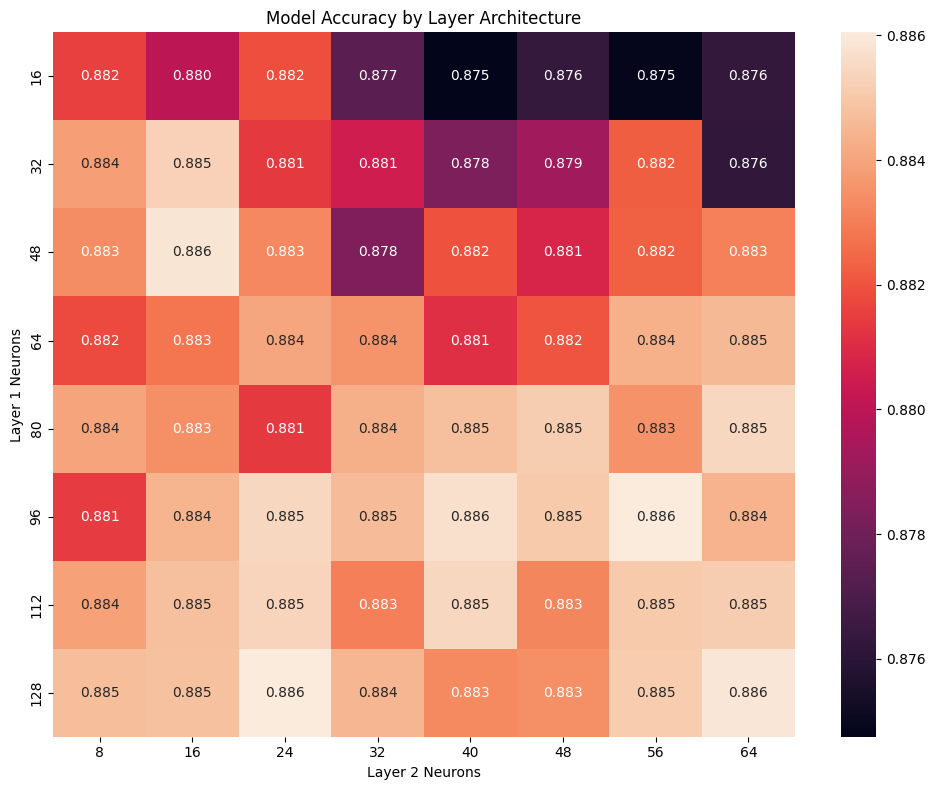

In [37]:
# Visualize results
import matplotlib.pyplot as plt
import seaborn as sns

# Create accuracy heatmap
accuracy_data = np.zeros((len(layer1_sizes), len(layer2_sizes)))
for result in all_results:
    i = list(layer1_sizes).index(result['layer1_size'])
    j = list(layer2_sizes).index(result['layer2_size'])
    accuracy_data[i, j] = result['mean_accuracy']

plt.figure(figsize=(10, 8))
sns.heatmap(accuracy_data, annot=True, fmt=".3f", 
            xticklabels=layer2_sizes, yticklabels=layer1_sizes)
plt.xlabel('Layer 2 Neurons')
plt.ylabel('Layer 1 Neurons')
plt.title('Model Accuracy by Layer Architecture')
plt.tight_layout()
plt.savefig('architecture_optimization.png')
plt.show()

In [ ]:
#Se busca el mejor parámetro para la cantidad de neuronas en la capa oculta

# neurons = np.arange(2,30,1)
# epochs = 40
# lr = 0.005
# val_scores_hl = []
# batch_size = 20000
# cv = 5 # Cross validation
# for n_neurons in neurons:
#     val_scores_hl_cv = []
#     for j in range(cv):
#         X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
#         X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2)
#         traindata = Data(X_train, Y_train)
#         valdata = Data(X_val, Y_val)
#         trainloader = DataLoader(traindata, batch_size=batch_size,
#                          shuffle=True, num_workers=10)
#         val_loader = DataLoader(valdata, batch_size=batch_size, shuffle=False, num_workers=10)
#         testdata = Data(X_test, Y_test)
#         testloader = DataLoader(testdata, batch_size=batch_size,
#                                 shuffle=True, num_workers=10)
#         score, best_val_loss = parameters_train(
#             epochs=epochs, 
#             ta=lr, 
#             hl_sizes=[64, 32],  # Example: two hidden layers with 64 and 32 neurons
#             dropout_rate=0.2,
#             trainloader=trainloader, 
#             val_loader=val_loader, 
#             testloader=testloader,
#             patience=5  # Stop if no improvement for 5 epochs
#         )
#         val_scores_hl_cv.append(score)
#     val_scores_hl.append(np.mean(val_scores_hl_cv))

In [ ]:
# #Se encuentra la mejor cantidad de puntos en la capa oculta
# ind = np.argmax(val_scores_hl)
# hl_star = hd[ind] #Resultó ser 17 25
# print('HL_star =', hl_star)

# plt.plot(hd,val_scores_hl)
# plt.plot(np.ones(11)*hl_star,np.arange(0,1.1,0.1),'--r')
# #plt.xlim(0.9,1)
# #plt.ylim(0.9,1)
# plt.xlabel('HL')
# plt.ylabel('Mean Cross-Validation Accuracy')
# plt.grid(True)
# plt.show()

In [38]:
best_architecture

{'layer1_size': 128,
 'layer2_size': 24,
 'mean_accuracy': 0.8860479945065052,
 'std_accuracy': 0.0009239387057352373,
 'mean_val_loss': 0.2689597472548485,
 'cv_scores': [0.8847040502262388,
  0.8860528994126375,
  0.8873220438743854,
  0.8867273240058369,
  0.8854336550134272],
 'cv_val_losses': [0.2664453610777855,
  0.2723706513643265,
  0.2669626995921135,
  0.2689121291041374,
  0.2701078951358795]}

In [ ]:
[best_architecture['layer1_size'],best_architecture['layer2_size']]

In [44]:
def optimize_learning_rate(
    X, y, 
    best_architecture,
    lr_range=np.logspace(-5, -2, 10),  # Log scale from 1e-5 to 1e-2
    epochs=40,
    dropout_rate=0.2,
    batch_size=500,
    cv=4,
    patience=5
):
    """
    Find optimal learning rate for a neural network with fixed architecture.
    
    Args:
        X: Input features
        y: Target labels
        best_architecture: Dictionary containing optimal layer sizes
        lr_range: Range of learning rates to try
        epochs: Maximum number of epochs for training
        dropout_rate: Dropout probability
        batch_size: Batch size for training
        cv: Number of cross-validation folds
        patience: Early stopping patience
        input_dim: Input dimension (features)
        output_dim: Output dimension (classes)
        
    Returns:
        best_lr: Best learning rate found
        results: Full results for all learning rates tested
    """
    
    # Store results
    results = []
    
    # Try each learning rate
    for lr in lr_range:
        print(f"\nTesting learning rate: {lr:.6f}")
        
        # Cross validation scores
        cv_scores = []
        cv_val_losses = []
        cv_epochs_used = []  # Track how many epochs were actually used before early stopping
        
        # Run cross-validation
        for j in range(cv):
            print(f"  CV fold {j+1}/{cv}")
            
            # Split data into train, validation, and test sets
            X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
            X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2)
            
            # Create data loaders
            traindata = Data(X_train, Y_train)
            valdata = Data(X_val, Y_val)
            testdata = Data(X_test, Y_test)
            
            trainloader = DataLoader(traindata, batch_size=batch_size, shuffle=True, num_workers=10)
            val_loader = DataLoader(valdata, batch_size=batch_size, shuffle=False, num_workers=10)
            testloader = DataLoader(testdata, batch_size=batch_size, shuffle=False, num_workers=10)
            
            # Train the model with this learning rate
            score, val_loss, epochs_used = parameters_train(
                epochs=epochs,
                ta=lr,
                hl_sizes=[best_architecture['layer1_size'], best_architecture['layer2_size']],
                dropout_rate=dropout_rate,
                trainloader=trainloader,
                val_loader=val_loader,
                testloader=testloader,
                patience=patience
            )
            
            cv_scores.append(score)
            cv_val_losses.append(val_loss)
            cv_epochs_used.append(epochs_used)
        
        # Calculate average performance across CV folds
        mean_score = np.mean(cv_scores)
        std_score = np.std(cv_scores)
        mean_val_loss = np.mean(cv_val_losses)
        mean_epochs = np.mean(cv_epochs_used)
        
        print(f"Learning rate {lr:.6f} - "
              f"Avg Accuracy: {mean_score:.4f} ± {std_score:.4f}, "
              f"Avg Val Loss: {mean_val_loss:.4f}, "
              f"Avg Epochs: {mean_epochs:.1f}")
        
        # Store results
        results.append({
            'learning_rate': lr,
            'mean_accuracy': mean_score,
            'std_accuracy': std_score,
            'mean_val_loss': mean_val_loss,
            'mean_epochs': mean_epochs,
            'cv_scores': cv_scores.copy(),
            'cv_val_losses': cv_val_losses.copy(),
            'cv_epochs': cv_epochs_used.copy()
        })
    
    # Find best learning rate based on mean accuracy
    results.sort(key=lambda x: x['mean_accuracy'], reverse=True)
    best_lr_result = results[0]
    
    print("\n=== Best Learning Rate Found ===")
    print(f"Learning rate: {best_lr_result['learning_rate']:.6f}")
    print(f"Test accuracy: {best_lr_result['mean_accuracy']:.4f} ± {best_lr_result['std_accuracy']:.4f}")
    print(f"Validation loss: {best_lr_result['mean_val_loss']:.4f}")
    print(f"Average epochs used: {best_lr_result['mean_epochs']:.1f}")
    
    # Plot results
    plt.figure(figsize=(12, 8))
    
    # Plot 1: Accuracy vs Learning Rate
    plt.subplot(2, 1, 1)
    lr_values = [r['learning_rate'] for r in results]
    accuracy_values = [r['mean_accuracy'] for r in results]
    error_values = [r['std_accuracy'] for r in results]
    
    plt.errorbar(lr_values, accuracy_values, yerr=error_values, fmt='o-')
    plt.xscale('log')
    plt.grid(True, which="both", ls="--")
    plt.xlabel('Learning Rate')
    plt.ylabel('Accuracy')
    plt.title('Model Accuracy vs Learning Rate')
    
    # Plot 2: Loss vs Learning Rate
    plt.subplot(2, 1, 2)
    loss_values = [r['mean_val_loss'] for r in results]
    plt.plot(lr_values, loss_values, 'o-')
    plt.xscale('log')
    plt.grid(True, which="both", ls="--")
    plt.xlabel('Learning Rate')
    plt.ylabel('Validation Loss')
    plt.title('Validation Loss vs Learning Rate')
    
    plt.tight_layout()
    plt.savefig('learning_rate_optimization.png')
    plt.show()
    
    return best_lr_result['learning_rate'], results


Testing learning rate: 0.000010
  CV fold 1/4


/home/juda/anaconda3/envs/hides-s5p/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/40] training loss: 0.98810
Epoch [1/40] validation loss: 0.83544
New best model saved with validation loss: 0.83544
Current learning rate: 0.000010
Epoch [2/40] training loss: 0.80493
Epoch [2/40] validation loss: 0.71695
New best model saved with validation loss: 0.71695
Current learning rate: 0.000010
Epoch [3/40] training loss: 0.71402
Epoch [3/40] validation loss: 0.65257
New best model saved with validation loss: 0.65257
Current learning rate: 0.000010
Epoch [4/40] training loss: 0.65826
Epoch [4/40] validation loss: 0.61113
New best model saved with validation loss: 0.61113
Current learning rate: 0.000010
Epoch [5/40] training loss: 0.61717
Epoch [5/40] validation loss: 0.57766
New best model saved with validation loss: 0.57766
Current learning rate: 0.000010
Epoch [6/40] training loss: 0.58236
Epoch [6/40] validation loss: 0.54445
New best model saved with validation loss: 0.54445
Current learning rate: 0.000010
Epoch [7/40] training loss: 0.55357
Epoch [7/40] validatio

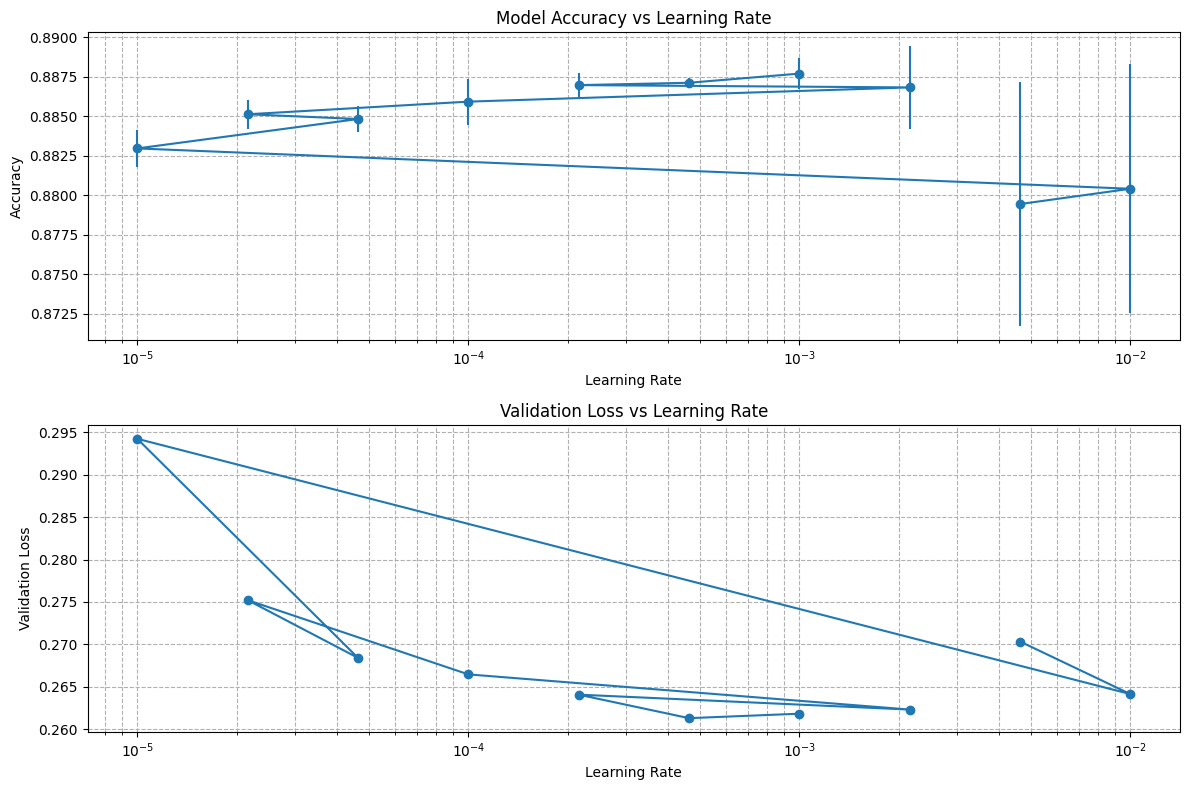

Best learning rate: 0.001


In [49]:
# Define learning rate range to search (logarithmic scale)
lr_range = np.logspace(-5, -2, 10)  # 10 points from 1e-5 to 1e-2

# Run optimization
best_lr, lr_results = optimize_learning_rate(
    X, y,
    best_architecture=best_architecture,
    lr_range=lr_range,
    epochs=40,
    dropout_rate=0.2,
    batch_size=500,
    cv=4,
    patience=5
)

print(f"Best learning rate: {best_lr}")

In [ ]:
# # Se busca el mejor valor para la tasa de aprendizaje
# epochs = 40
# lr = np.arange(1e-5,0.01,5e-4)
# val_scores_lr = []
# batch_size = 500
# cv=4
# for i in lr:
#     val_scores_lr_cv=[]
#     for j in range(cv):
        
#         # Split data into train, validation, and test sets
#         X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
#         X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2)
        
#         # Create data loaders
#         traindata = Data(X_train, Y_train)
#         valdata = Data(X_val, Y_val)
#         testdata = Data(X_test, Y_test)
        
#         trainloader = DataLoader(traindata, batch_size=batch_size, shuffle=True, num_workers=10)
#         val_loader = DataLoader(valdata, batch_size=batch_size, shuffle=False, num_workers=10)
#         testloader = DataLoader(testdata, batch_size=batch_size, shuffle=False, num_workers=10)
        
#         score, val_loss = parameters_train(
#                 epochs=epochs,
#                 ta=i,
#                 hl_sizes=[best_architecture['layer1_size'],best_architecture['layer2_size']]
#                 dropout_rate=0.2,
#                 trainloader=trainloader,
#                 val_loader=val_loader,
#                 testloader=testloader
#             )
#         val_scores_lr_cv.append(score)
#     val_scores_lr.append(np.mean(val_scores_lr_cv))



In [ ]:
# ind = np.argmax(val_scores_lr)
# lr_star = lr[ind] # resulto ser LR_star =0.00601
# print('LR_star =', lr_star)

# plt.plot(lr,val_scores_lr)
# plt.plot(np.ones(11)*lr_star,np.arange(0,1.1,0.1),'--r')
# #plt.xlim(0.95,1)
# #plt.ylim(0.95,1)
# plt.xlabel('Learning Rate')
# plt.ylabel('Mean Cross-Validation Accuracy')
# plt.grid(True)
# plt.show()

In [50]:

def train_and_save_final_model(best_lr, best_architecture, X, y, batch_size=500, epochs=40, dropout_rate=0.2, patience=5, model_path='best_model.pth'):
    """
    Train the final model with the best hyperparameters and save it
    
    Parameters:
    - best_lr: Best learning rate found during hyperparameter tuning
    - best_architecture: Dictionary containing the best architecture parameters
    - X: Feature data
    - y: Target labels
    - batch_size: Batch size for training
    - epochs: Maximum number of training epochs
    - dropout_rate: Dropout rate for regularization
    - patience: Early stopping patience
    - model_path: Path to save the trained model
    
    Returns:
    - clf: Trained model
    - test_score: Performance on test set
    - epochs_used: Number of epochs used for training
    """
    # Split data into train, validation, and test sets
    X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
    X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2)
    
    # Create data loaders
    traindata = Data(X_train, Y_train)
    valdata = Data(X_val, Y_val)
    testdata = Data(X_test, Y_test)
    
    trainloader = DataLoader(traindata, batch_size=batch_size, shuffle=True, num_workers=10)
    val_loader = DataLoader(valdata, batch_size=batch_size, shuffle=False, num_workers=10)
    testloader = DataLoader(testdata, batch_size=batch_size, shuffle=False, num_workers=10)
    
    # Initialize model with best architecture
    hl_sizes = [best_architecture['layer1_size'], best_architecture['layer2_size']]
    clf = Network(hl_sizes, dropout_rate)
    
    # Train the model
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(clf.parameters(), lr=best_lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',
        factor=0.5,
        patience=3,
        verbose=True,
        min_lr=1e-6
    )
    
    # Early stopping variables
    best_val_loss = float('inf')
    early_stop_counter = 0
    best_model_state = None
    epochs_used = epochs
    
    print(f"Training final model with architecture: {hl_sizes}, lr: {best_lr}")
    
    for epoch in range(epochs):
        # Training phase
        clf.train()
        running_loss = 0.0
        batch_count = 0
        
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            optimizer.zero_grad()
            outputs = clf(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            batch_count += 1
        
        avg_train_loss = running_loss / batch_count
        print(f'Epoch [{epoch + 1}/{epochs}] training loss: {avg_train_loss:.5f}')
        
        # Validation phase
        val_loss = validate(clf, val_loader, criterion)
        print(f'Epoch [{epoch + 1}/{epochs}] validation loss: {val_loss:.5f}')
        
        # Update learning rate based on validation loss
        scheduler.step(val_loss)
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            best_model_state = clf.state_dict().copy()
            print(f'New best model saved with validation loss: {val_loss:.5f}')
        else:
            early_stop_counter += 1
            print(f'Early stopping counter: {early_stop_counter}/{patience}')
            
        if early_stop_counter >= patience:
            print(f'Early stopping triggered after {epoch + 1} epochs')
            epochs_used = epoch + 1
            break
        
        # Print current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Current learning rate: {current_lr:.6f}')
    
    # Load the best model
    if best_model_state is not None:
        clf.load_state_dict(best_model_state)
        print("Training completed. Loaded best model.")
    
    # Save the model
    torch.save({
        'model_state_dict': clf.state_dict(),
        'architecture': hl_sizes,
        'dropout_rate': dropout_rate,
        'optimizer_state_dict': optimizer.state_dict(),
        'epochs_used': epochs_used,
        'val_loss': best_val_loss
    }, model_path)
    print(f"Model saved to {model_path}")
    
    # Evaluate on test set
    test_score = test_val(clf, testloader)
    print(f"Test accuracy: {test_score:.4f}")
    
    return clf, test_score, epochs_used

In [51]:
# Example usage
best_model, test_score, epochs_used = train_and_save_final_model(
    best_lr=best_lr,
    best_architecture=best_architecture,
    X=X,
    y=y,
    batch_size=500,
    epochs=40,
    dropout_rate=0.2,
    patience=5,
    model_path='best_model.pth'
)

# To load the model later
def load_model(model_path='best_model.pth'):
    """
    Load a saved model
    
    Parameters:
    - model_path: Path to the saved model
    
    Returns:
    - model: Loaded model
    """
    checkpoint = torch.load(model_path)
    model = Network(checkpoint['architecture'], checkpoint['dropout_rate'])
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    print(f"Model loaded from {model_path}")
    print(f"Architecture: {checkpoint['architecture']}")
    print(f"Validation loss: {checkpoint['val_loss']:.5f}")
    print(f"Trained for {checkpoint['epochs_used']} epochs")
    return model



Training final model with architecture: [128, 24], lr: 0.001


/home/juda/anaconda3/envs/hides-s5p/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/40] training loss: 0.36505
Epoch [1/40] validation loss: 0.28480
New best model saved with validation loss: 0.28480
Current learning rate: 0.001000
Epoch [2/40] training loss: 0.29711
Epoch [2/40] validation loss: 0.27665
New best model saved with validation loss: 0.27665
Current learning rate: 0.001000
Epoch [3/40] training loss: 0.28914
Epoch [3/40] validation loss: 0.27012
New best model saved with validation loss: 0.27012
Current learning rate: 0.001000
Epoch [4/40] training loss: 0.28530
Epoch [4/40] validation loss: 0.26764
New best model saved with validation loss: 0.26764
Current learning rate: 0.001000
Epoch [5/40] training loss: 0.28326
Epoch [5/40] validation loss: 0.26856
Early stopping counter: 1/5
Current learning rate: 0.001000
Epoch [6/40] training loss: 0.28074
Epoch [6/40] validation loss: 0.26684
New best model saved with validation loss: 0.26684
Current learning rate: 0.001000
Epoch [7/40] training loss: 0.28071
Epoch [7/40] validation loss: 0.26725
Early s

In [52]:
# Loading and using the model
loaded_model = load_model('best_model.pth')

Model loaded from best_model.pth
Architecture: [128, 24]
Validation loss: 0.25887
Trained for 40 epochs


/tmp/ipykernel_18832/939958828.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


In [ ]:
# # save the trained model
# clf = Network(hl_star)
# criterion = nn.MultiMarginLoss()#nn.MultiMarginLoss()#nn.HingeEmbeddingLoss#nn.MultiLabelMarginLoss()##
# optimizer = torch.optim.Adam(clf.parameters(), lr=lr_star)
# epochs = 40
# for epoch in range(epochs):
#   running_loss = 0.0
#   for i, data in enumerate(trainloader, 0):
#     inputs, labels = data
#     # set optimizer to zero grad to remove previous epoch gradients
#     optimizer.zero_grad()
#     # forward propagation
#     outputs = clf(inputs)
#     loss = criterion(outputs, labels)
#     # backward propagation
#     loss.backward()
#     # optimize
#     optimizer.step()
#     running_loss += loss.item()
#   # display statistics
#   print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.5f}')
# PATH = 'mymodel_prueba_corrected_filtered.pth'
# torch.save(clf.state_dict(), PATH)

### ----------------------

In [34]:
# # load the trained model
# PATH = 'mymodel_prueba_corrected_filtered.pth'
# clf = Network(22)
# clf.load_state_dict(torch.load(PATH))

/tmp/ipykernel_502494/1516079928.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  clf.load_state_dict(torch.load(PATH))


<All keys matched successfully>

In [55]:
def predict_with_model(model, X, batch_size=None):
    """
    Use the trained model to make predictions on data
    
    Parameters:
    - model: Trained PyTorch model
    - X: Input features to predict on
    - batch_size: Batch size for prediction (defaults to full dataset)
    
    Returns:
    - y_pred: NumPy array of predictions
    - probabilities: NumPy array of class probabilities
    """
    # Set model to evaluation mode
    model.eval()
    
    # If batch_size is not specified, use the full dataset
    if batch_size is None:
        batch_size = len(X)
    
    # Create DataLoader for the input data
    # Note: no need for labels in prediction, but your Data class might require them
    # If your Data class requires labels during initialization, you can pass dummy labels
    # Create dummy labels as numpy array
    dummy_labels = np.zeros(len(X), dtype=np.int64)
    testdata = Data(X[:,[0,1]], dummy_labels)
    testloader = DataLoader(testdata, batch_size=batch_size, shuffle=False, num_workers=10)
    
    # Lists to store predictions and probabilities
    all_predictions = []
    all_probabilities = []
    
    # Disable gradient calculation for inference
    with torch.no_grad():
        for data in testloader:
            inputs, _ = data
            # Forward pass
            outputs = model(inputs)
            # Get predictions
            _, predicted = torch.max(outputs.data, 1)
            # Get probabilities using softmax
            probs = torch.nn.functional.softmax(outputs, dim=1)
            
            # Append batch predictions and probabilities
            all_predictions.append(predicted)
            all_probabilities.append(probs)
    
    # Concatenate all batch predictions and convert to NumPy
    y_pred = torch.cat(all_predictions).cpu().numpy()
    probabilities = torch.cat(all_probabilities).cpu().numpy()
    
    return y_pred, probabilities

In [57]:
# Make predictions
predictions, probabilities = predict_with_model(loaded_model, X)

# Print some statistics
print(f"Predictions shape: {predictions.shape}")
print(f"Probabilities shape: {probabilities.shape}")

# If you have true labels, you can calculate accuracy
if y is not None:
    accuracy = (predictions == y).mean()
    print(f"Accuracy: {accuracy:.4f}")


Predictions shape: (494246,)
Probabilities shape: (494246, 3)
Accuracy: 0.8864


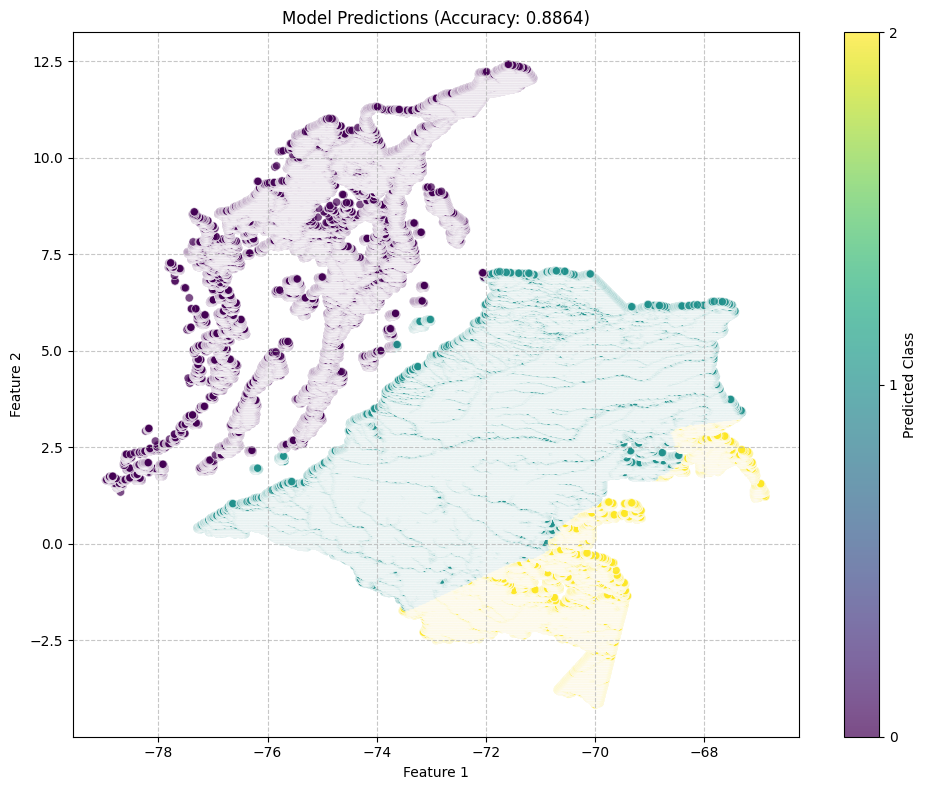

In [58]:
def plot_predictions(X, predictions, probabilities=None, title="Model Predictions"):
    """
    Create a scatter plot of the input features colored by predicted classes
    
    Parameters:
    - X: Input features (first two columns will be used for x and y axes)
    - predictions: Predicted class labels
    - probabilities: Optional class probabilities for sizing or additional visualization
    - title: Plot title
    """
    # Set up the figure and axis
    plt.figure(figsize=(10, 8))
    
    # Create a scatter plot with points colored by predicted class
    scatter = plt.scatter(X[:, 0], X[:, 1], c=predictions, cmap='viridis', 
                          alpha=0.7, edgecolors='w', linewidths=0.5)
    
    # Add a color bar to show the mapping of colors to classes
    cbar = plt.colorbar(scatter)
    cbar.set_label('Predicted Class')
    
    # Set integer ticks on the colorbar if the number of classes is small
    unique_classes = np.unique(predictions)
    if len(unique_classes) <= 10:  # Only set integer ticks if there are 10 or fewer classes
        cbar.set_ticks(unique_classes)
    
    # Add axis labels and title
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    
    # Add grid for better readability
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Show the plot
    plt.tight_layout()
    plt.show()

# Plot the predictions
plot_predictions(X, predictions, title=f"Model Predictions (Accuracy: {accuracy:.4f})")


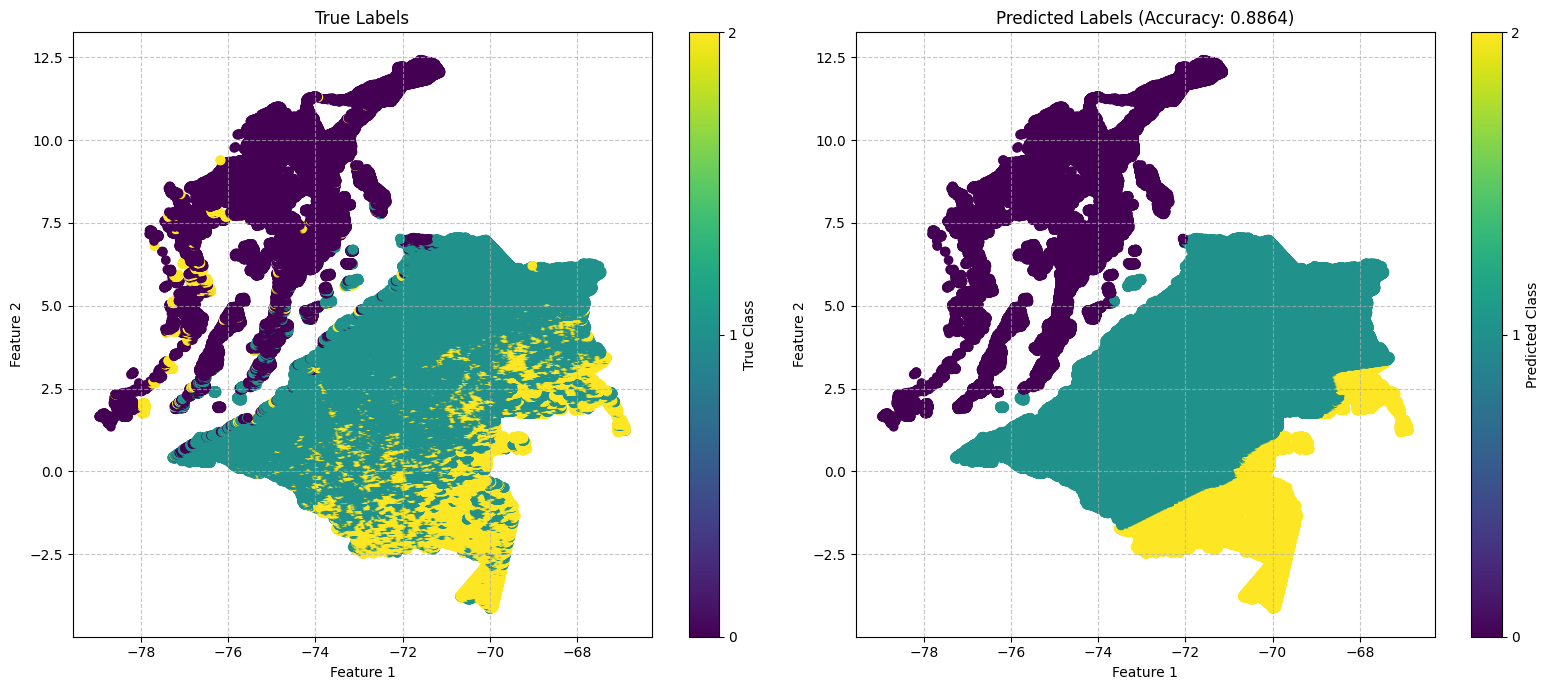

In [61]:
# If you want to compare with true labels
def plot_comparison(X, predictions, true_labels):
    """
    Create side-by-side plots comparing predicted vs true labels
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot true labels
    scatter1 = ax1.scatter(X[:, 0], X[:, 1], c=true_labels)
    ax1.set_title("True Labels")
    ax1.set_xlabel("Feature 1")
    ax1.set_ylabel("Feature 2")
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot predicted labels
    scatter2 = ax2.scatter(X[:, 0], X[:, 1], c=predictions)
    ax2.set_title(f"Predicted Labels (Accuracy: {accuracy:.4f})")
    ax2.set_xlabel("Feature 1")
    ax2.set_ylabel("Feature 2")
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Add colorbars
    cbar1 = fig.colorbar(scatter1, ax=ax1)
    cbar1.set_label('True Class')
    
    cbar2 = fig.colorbar(scatter2, ax=ax2)
    cbar2.set_label('Predicted Class')
    
    # Set integer ticks on the colorbars if the number of classes is small
    unique_classes = np.unique(np.concatenate([true_labels, predictions]))
    if len(unique_classes) <= 10:
        cbar1.set_ticks(np.unique(true_labels))
        cbar2.set_ticks(np.unique(predictions))
    
    plt.tight_layout()
    plt.show()

plot_comparison(X, predictions, y)

In [ ]:
plot_comparison(X, predictions, y.numpy())

In [35]:
# y_pred=[]
# batch_size=len(y)
# testdata = Data(X[:,[0,1]], y)
# testloader = DataLoader(testdata, batch_size=batch_size, shuffle=True, num_workers=10)

# for data in testloader:
#     inputs, labels = data
#     # calculate output by running through the network
#     outputs = loaded_model(inputs)
#     # get the predictions
#     __, predicted = torch.max(outputs.data, 1)
#     y_pred.append(predicted)


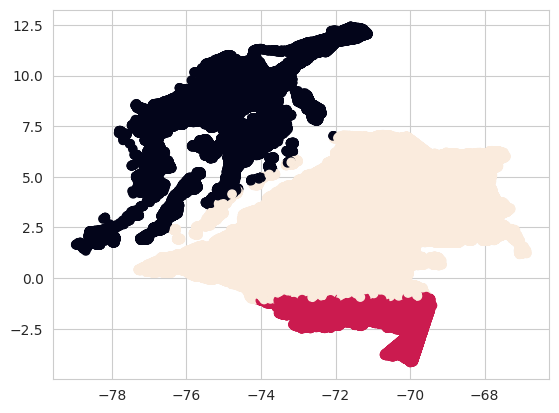

In [36]:
plt.scatter(inputs[:,0],inputs[:,1],c=predicted)

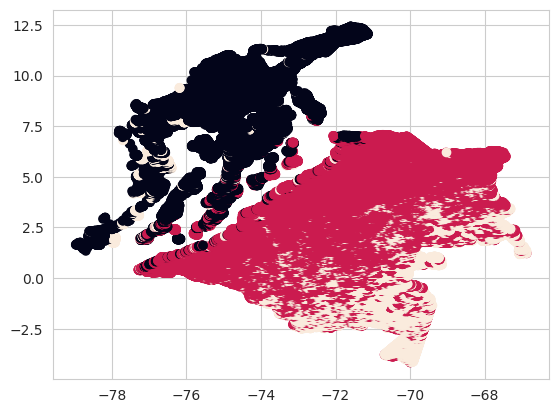

In [37]:
plt.scatter(X[:,0],X[:,1],c=y)

In [62]:
import ee
from shapely.geometry import shape, Point
ee.Initialize()

In [63]:
pacifico_asset = ee.FeatureCollection('projects/ee-hides/assets/pacifico')
magdalena_asset = ee.FeatureCollection('projects/ee-hides/assets/magdalena')


In [64]:
# Convert MultiPolygon from FeatureCollection to Shapely polygons
features_1 = pacifico_asset.getInfo()['features']
shapely_polygons = [shape(feat['geometry']) for feat in features_1]

# Update 'cluster' column with a fixed value if the point is inside any polygon
def update_cluster(row):
    point = Point(row['longitude'], row['latitude'])
    for polygon in shapely_polygons:
        if polygon.contains(point):
            return 3  # Set the fixed cluster value to 3
    return row['cluster']  # Keep the original cluster if not inside any polygon



In [67]:

predicted_cluster_array = predictions
lon_array = X[:, 0] # Extract longitude values
lat_array = X[:, 1]  # Extract latitude values

# Round the longitude array to 3 decimal places
lon_array_rounded = np.round(lon_array, 3)
lat_array_rounded = np.round(lat_array, 3)

# Create the DataFrame with the rounded longitude values
r_refined = pd.DataFrame({
    'latitude': lat_array_rounded,
    'longitude': lon_array_rounded,
    'cluster': predicted_cluster_array
})


r[['latitude', 'longitude']] = r[['latitude', 'longitude']].round(3)
r

,latitude,longitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,cluster
0,-4.165,-69.995,1940.140508,1
1,-4.155,-70.005,1940.140503,1
2,-4.135,-69.965,1879.711405,2
3,-4.135,-69.955,1879.711295,2
4,-4.135,-69.945,1879.711346,2
...,...,...,...,...
494249,12.415,-71.585,1941.189894,0
494250,12.415,-71.575,1940.603705,0
494251,12.425,-71.605,1944.441511,0
494252,12.425,-71.595,1944.023515,0


## matching the measure values in their correct place

In [68]:
## Computationally efficient mclassmethod # pribarlo y mejorarlo

# Round coordinates in both DataFrames to 3 decimals upfront
r_refined['lat_round'] = r_refined['latitude'].round(3)
r_refined['lon_round'] = r_refined['longitude'].round(3)
r['lat_round'] = r['latitude'].round(3)
r['lon_round'] = r['longitude'].round(3)

# Create a mapping of rounded coordinates to CH4 values (using first occurrence in `r`)
# Drop duplicates to avoid multiple matches
r_mapping = r.drop_duplicates(subset=['lat_round', 'lon_round'])[['lat_round', 'lon_round', 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected']]

# Merge the mapping onto r_refined using left join (to retain all r_refined rows)
r_refined = r_refined.merge(
    r_mapping,
    on=['lat_round', 'lon_round'],
    how='left'
).drop(columns=['lat_round', 'lon_round'])  # Remove temporary columns

r_refined

,latitude,longitude,cluster,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,-4.165,-69.995,2,1940.140508
1,-4.155,-70.005,2,1940.140503
2,-4.135,-69.965,2,1879.711405
3,-4.135,-69.955,2,1879.711295
4,-4.135,-69.945,2,1879.711346
...,...,...,...,...
494241,12.415,-71.585,0,1941.189894
494242,12.415,-71.575,0,1940.603705
494243,12.425,-71.605,0,1944.441511
494244,12.425,-71.595,0,1944.023515


In [43]:
### Metodo usando loops computacionalmente ineficiente

sorted_array = []
for i in range(len(r_refined['longitude'])):
    lat, lon = r_refined.loc[i, ['latitude', 'longitude']]
    lat = round(lat,3)
    lon = round(lon,3)
    value_i = r[(r['longitude'] == lon) & (r['latitude'] == lat)]['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
    
    if not value_i.empty:
        sorted_array.append(value_i)
    else:
        sorted_array.append(float("nan"))
        
r_refined['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'] = sorted_array
r_refined

,latitude,longitude,cluster,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
0,5.555,-71.135002,2,378289 1911.735289 Name: CH4_column_volume_...
1,5.515,-69.675003,2,376871 1893.415688 Name: CH4_column_volume_...
2,5.395,-69.345001,2,372317 1900.463836 Name: CH4_column_volume_...
3,6.195,-75.425003,0,401518 1907.258504 Name: CH4_column_volume_...
4,5.125,-69.614998,2,362161 1895.052304 Name: CH4_column_volume_...
...,...,...,...,...
494241,0.225,-75.794998,2,91194 1887.76309 Name: CH4_column_volume_mi...
494242,10.075,-74.394997,0,472364 1915.629199 Name: CH4_column_volume_...
494243,3.225,-68.285004,2,260878 1875.22195 Name: CH4_column_volume_m...
494244,4.155,-74.985001,0,313978 1914.157043 Name: CH4_column_volume_...


In [69]:

####### Codigo necesario en caso de hacer el metodo mas eficiente con merge o alguna otra función

# Merge 'r_refined' with 'r', selecting only the 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected' column from 'r'
# r_refined = pd.merge(
#     r_refined, 
#     r[['latitude', 'longitude', 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected']],  # Select columns from r
#     on=['latitude', 'longitude'],  # Columns to merge on
#     how='inner'  # Merge type (e.g., inner, left, right, outer)
# )


In [70]:
# updating the clusters and adding separately the pacifico and magdalena bassin, resulting in 5 clusters instead of 3

r_refined['cluster'] = r_refined.apply(update_cluster, axis=1)

In [71]:
# Convert MultiPolygon from FeatureCollection to Shapely polygons
features_2 = magdalena_asset.getInfo()['features']
shapely_polygons = [shape(feat['geometry']) for feat in features_2]

# Update 'cluster' column with a fixed value if the point is inside any polygon
def update_cluster(row):
    point = Point(row['longitude'], row['latitude'])
    for polygon in shapely_polygons:
        if polygon.contains(point):
            return 4  # Set the fixed cluster value to 3
    return row['cluster']  # Keep the original cluster if not inside any polygon



In [72]:
r_refined['cluster'] = r_refined.apply(update_cluster, axis=1)

r_refined = r_refined.sort_values(by='cluster')
# sort the dataframe by clusters_100.png



In [75]:
r_refined

,latitude,longitude,cluster,CH4_column_volume_mixing_ratio_dry_air_bias_corrected
494245,12.425,-71.585,0.0,1942.809693
436061,7.985,-73.485,0.0,1922.442990
436062,7.985,-73.475,0.0,1925.774203
436063,7.985,-73.465,0.0,1925.534828
436064,7.985,-73.455,0.0,1930.218229
...,...,...,...,...
322948,4.315,-74.915,4.0,1912.852122
322949,4.315,-74.835,4.0,1926.464317
322950,4.315,-74.825,4.0,1930.544849
322952,4.315,-74.805,4.0,1921.848952


In [76]:
# Extract the first value from each Series in the column
#r_refined['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'] = r_refined['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].apply(lambda x: x.iloc[0])


5
GeoDataFrame already has CRS: EPSG:3857


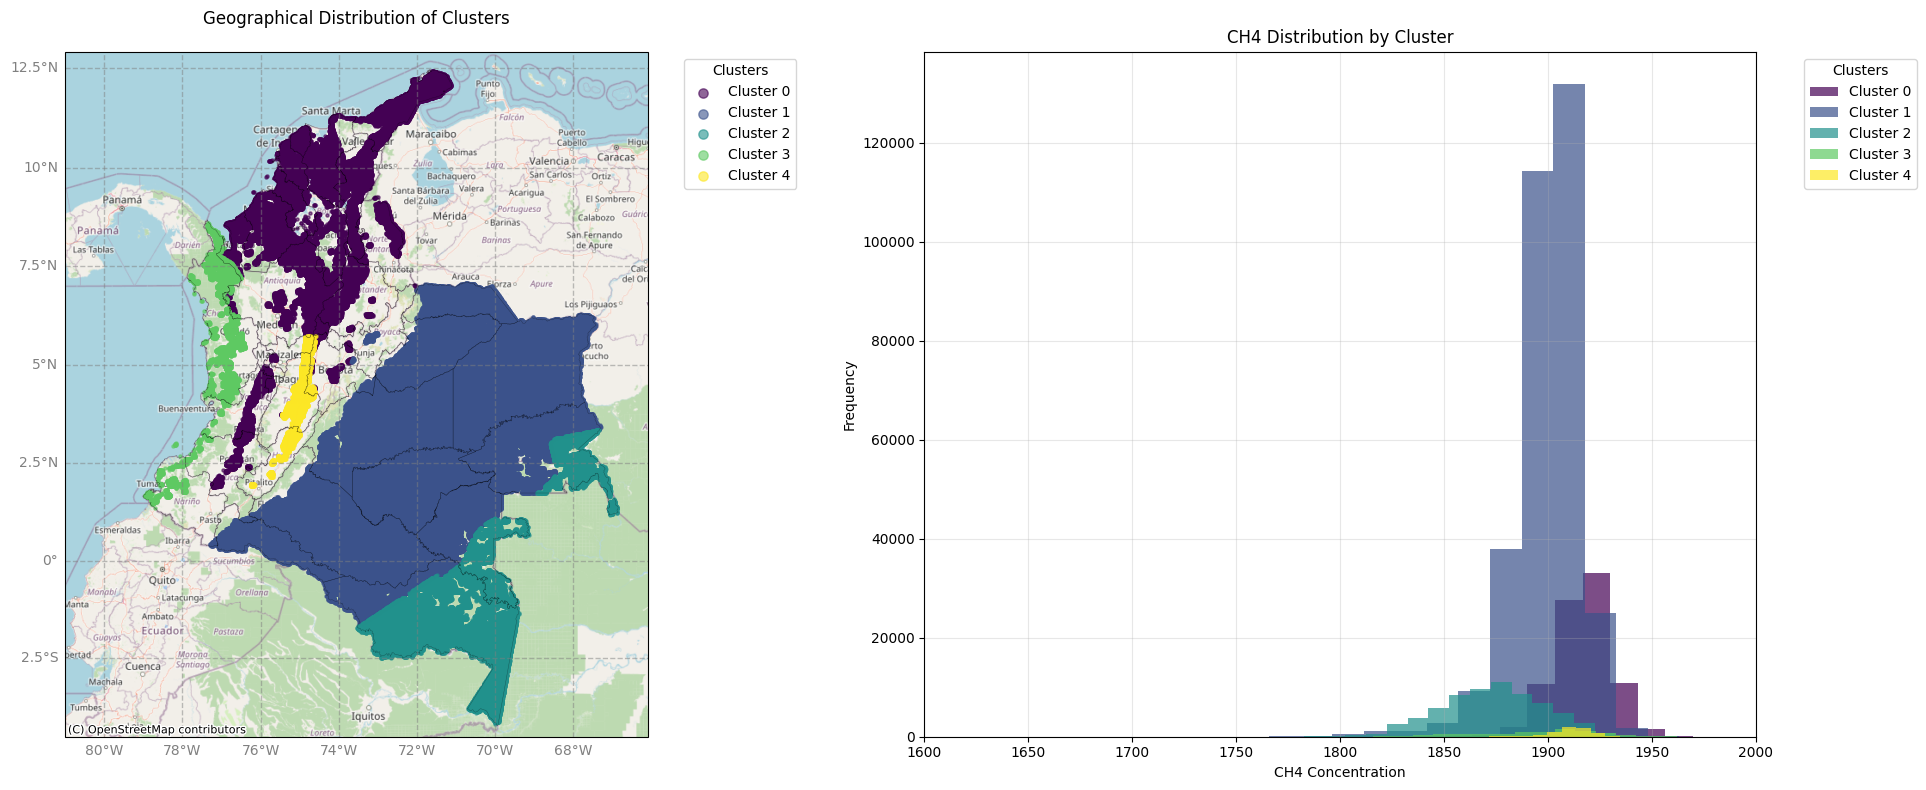


Cluster Statistics:
        CH4_column_volume_mixing_ratio_dry_air_bias_corrected                 \
                                                         mean    std   count   
cluster                                                                        
0.0                                                1916.17     14.39   86652   
1.0                                                1899.92     15.98  325759   
2.0                                                1873.29     24.99   66593   
3.0                                                1895.03     28.40    8847   
4.0                                                1911.13     11.45    6395   

        longitude latitude  
             mean     mean  
cluster                     
0.0        -74.44     8.65  
1.0        -71.75     2.71  
2.0        -70.59    -1.06  
3.0        -77.12     5.58  
4.0        -75.04     4.08  


In [78]:
# Create figure and axes
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, figure=fig)

# First subplot - Map with clusters
ax1 = fig.add_subplot(gs[0], projection=ccrs.epsg(3857))

# Set map extent
extent = [-81, -66.1, -4.5, 12.9]
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Create GeoDataFrame from your clusters data
gdf_points = gpd.GeoDataFrame(
    r_refined,
    geometry=gpd.points_from_xy(r_refined.longitude, r_refined.latitude),
    crs="EPSG:4326"
)

# Convert to web mercator for contextily basemap
gdf_points_mercator = gdf_points.to_crs(epsg=3857)

# Convertir la columna 'cluster' a enteros
gdf_points['cluster'] = gdf_points['cluster'].astype(int)

# Verificar los valores únicos después de la conversión
clusters = gdf_points['cluster'].unique()

print(len(clusters))
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))

# Plot clusters on map with legend
for cluster, color in zip(clusters, colors):
    cluster_data = gdf_points[gdf_points['cluster'] == cluster]
    ax1.scatter(
        cluster_data.longitude,
        cluster_data.latitude,
        color=color,
        label=f'Cluster {cluster}',  # Add cluster number as label
        transform=ccrs.PlateCarree(),
        s=5,  # Marker size
        alpha=0.6
    )

# Add basemap 
cx.add_basemap(ax1, 
               source=cx.providers.OpenStreetMap.Mapnik)

# Add gridlines
gl = ax1.gridlines(crs=ccrs.PlateCarree(), 
                   draw_labels=True,
                   linewidth=1, 
                   color='gray', 
                   alpha=0.5, 
                   linestyle='--')

gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Add colorbar to map
# cbar = plt.colorbar(scatter, ax=ax1)
# cbar.set_label('Cluster', fontsize=10)

# Add legend to map with larger points
legend = ax1.legend(
    title='Clusters', 
    loc='upper left', 
    bbox_to_anchor=(1.05, 1),
    markerscale=3  # Increase the size of points in the legend
)

# Adjust legend title font size
plt.setp(legend.get_title(), fontsize=10)



if gdf.crs is None:
    # Only set CRS if it doesn't have one
    gdf.set_crs(epsg=4326, inplace=True)
else:
    print("GeoDataFrame already has CRS:", gdf.crs)
gdf = gdf.to_crs(epsg=3857)
              
gdf.plot(ax=ax1, edgecolor='black', facecolor='none', linewidth=0.3, alpha=0.4)


# Add title to map
ax1.set_title('Geographical Distribution of Clusters', pad=20)





# Second subplot - Methane distribution
ax2 = fig.add_subplot(gs[1])
#colors = plt.cm.viridis(np.linspace(0, 1, optimal_k+2))  # Use same colormap as map

# color_f = np.zeros([5,4])
# color_f[0,:] = colors[1,:]
# color_f[1,:] = colors[2,:]
# color_f[2,:] = colors[0,:]
# color_f[3,:] = colors[4,:]
# color_f[4,:] = colors[3,:]


ax2.set_xlabel('CH4 Concentration')
ax2.set_ylabel('Frequency')
ax2.set_title('CH4 Distribution by Cluster')


for i in range(5):
    cluster_data = r_refined[r_refined['cluster'] == i]
    ax2.hist(cluster_data['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'], 
             alpha=0.7, 
             label=f'Cluster {i}',
             color=colors[i],  # Match colors with map
             bins=20)  # Adjust number of bins

# Add grid to histogram
ax2.grid(True, alpha=0.3)

# Customize histogram legend
ax2.legend(title='Clusters', 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left')

ax2.set_xlim([1600, 2000])


# Adjust layout and save
plt.tight_layout()
plt.savefig('clusters_modelo_updated_2lys.png', dpi=600, bbox_inches='tight')
plt.show()

# Print cluster statistics
print("\nCluster Statistics:")
print(r_refined.groupby('cluster').agg({
    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected': ['mean', 'std', 'count'],
    'longitude': 'mean',
    'latitude': 'mean'
}).round(2))

In [77]:
r_refined.to_csv('mean_values_clustered_model_updated.csv', index = False, encoding='utf-8')